In [15]:
import os
from pathlib import Path

# Asegurar que el kernel corre desde notebooks/ para que ../data y ../outputs funcionen
_cwd = Path.cwd()
if _cwd.name != "notebooks":
    _nb_dir = _cwd / "notebooks"
    if _nb_dir.is_dir():
        os.chdir(_nb_dir)

# Crear directorios si no existen
for _d in ["../outputs", "../data", "../models"]:
    Path(_d).mkdir(exist_ok=True)

print(f"cwd: {Path.cwd()}")

cwd: c:\Users\adria\OneDrive\Desktop\Proyecto de machine learning\notebooks


# Fase 4 — Feature Engineering

Unimos todos los datos y construimos la matriz de features completa.

### Features incluidas
| Feature | Fuente | Por qué importa |
|---|---|---|
| `eps_surprise_pct` | yfinance | **El predictor #1**: si la empresa superó o no las expectativas del analista |
| `momentum_5d` / `momentum_20d` | precios | Efecto "sell the news": si ya subió antes, tiende a caer post-earnings |
| `volatility_20d` | precios | Alta volatilidad previa = el mercado esperaba movimiento grande |
| `score_positivo` / `score_negativo` / `polaridad` | FinBERT | Tono de la transcripción |
| `kw_ratio` / `kw_cat_enc` | keywords | Palabras financieras positivas vs negativas |

## 1. Importar librerías

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tempfile
import warnings
import yfinance as yf
warnings.filterwarnings('ignore')
yf.set_tz_cache_location(tempfile.mkdtemp())

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 2. Cargar los datasets

In [17]:
df_retornos    = pd.read_csv('../data/retornos_earnings.csv')
df_sentimientos = pd.read_csv('../data/sentimientos.csv')

print(f'retornos:     {df_retornos.shape}    columnas: {list(df_retornos.columns)}')
print(f'sentimientos: {df_sentimientos.shape} columnas: {list(df_sentimientos.columns)}')

retornos:     (228, 9)    columnas: ['ticker', 'fecha_earnings', 'precio_antes', 'precio_despues', 'retorno_pct', 'direccion', 'momentum_5d', 'momentum_20d', 'volatility_20d']
sentimientos: (92, 12) columnas: ['ticker', 'q', 'date', 'sentimiento', 'score_positivo', 'score_negativo', 'score_neutral', 'polaridad', 'kw_positivos', 'kw_negativos', 'kw_ratio', 'kw_categoria']


## 3. Merge retornos + sentimientos

Convertimos `fecha_earnings` a trimestre calendario (`año_q`) y hacemos inner join con la columna `q` de sentimientos.

In [18]:
df_retornos['fecha_dt'] = pd.to_datetime(df_retornos['fecha_earnings'])
df_retornos['año_q'] = (
    df_retornos['fecha_dt'].dt.year.astype(str) + '-Q' +
    df_retornos['fecha_dt'].dt.quarter.astype(str)
)

cols_ret = ['ticker', 'año_q', 'fecha_earnings', 'fecha_dt',
            'retorno_pct', 'direccion', 'momentum_5d', 'momentum_20d', 'volatility_20d']

nlp_cols = ['ticker', 'q', 'score_positivo', 'score_negativo', 'score_neutral',
            'polaridad', 'kw_positivos', 'kw_negativos', 'kw_ratio', 'kw_categoria']

# Left join: conservamos TODOS los earnings calls del dataset de precios
# Los que no tienen transcripción reciben features NLP = neutral/0
df_merged = df_retornos[cols_ret].merge(
    df_sentimientos[nlp_cols],
    left_on=['ticker', 'año_q'],
    right_on=['ticker', 'q'],
    how='left'
)

df_merged['q'] = df_merged['q'].fillna(df_merged['año_q'])
df_merged = df_merged.drop(columns=['año_q'])
df_merged['tiene_transcripcion'] = (~df_merged['score_positivo'].isna()).astype(int)

nlp_fills = {
    'score_positivo': 0.0, 'score_negativo': 0.0, 'score_neutral': 1.0,
    'polaridad': 0.0, 'kw_positivos': 0, 'kw_negativos': 0,
    'kw_ratio': 0.0, 'kw_categoria': 'neutral',
}
for col, val in nlp_fills.items():
    df_merged[col] = df_merged[col].fillna(val)

print(f'Filas totales: {len(df_merged)}')
print(f'Con transcripción NLP: {df_merged["tiene_transcripcion"].sum()}')
print(f'Solo features cuantitativas: {(~df_merged["tiene_transcripcion"].astype(bool)).sum()}')
print(f'Tickers: {df_merged["ticker"].value_counts().to_dict()}')
print(f'Dirección: {df_merged["direccion"].value_counts().to_dict()}')

Filas totales: 228
Con transcripción NLP: 86
Solo features cuantitativas: 142
Tickers: {'TSLA': 21, 'NVDA': 21, 'AAPL': 20, 'MSFT': 20, 'GOOGL': 19, 'META': 19, 'NFLX': 19, 'AMZN': 19, 'V': 19, 'AMD': 17, 'JPM': 17, 'MA': 17}
Dirección: {'SUBE': 114, 'BAJA': 114}


## 3b. Features NLP del texto crudo

Extraemos señales directamente de las transcripciones:
- `uncertainty_score`: densidad de palabras de incertidumbre ("expect", "approximately", "may", etc.)
- `forward_guidance_score`: densidad de lenguaje prospectivo ("outlook", "next quarter", "guidance")
- `text_length_log`: log del largo del texto
- `question_density`: preguntas por oración (más preguntas de analistas = más escrutinio)
- `negative_words_score`: densidad de palabras negativas financieras ("decline", "headwind", etc.)

In [19]:
df_trans = pd.read_csv('../data/transcripciones_clean.csv')

def extract_text_features(texto):
    if pd.isna(texto) or not isinstance(texto, str) or len(texto.strip()) == 0:
        return dict(uncertainty_score=0.0, forward_guidance_score=0.0,
                    text_length_log=0.0, question_density=0.0, negative_words_score=0.0)
    texto_low = texto.lower()
    words = texto_low.split()
    n_words = max(len(words), 1)
    n_q = texto.count('?')
    n_sentences = max(texto.count('.') + n_q + texto.count('!'), 1)

    uncertainty = ['expect', 'approximately', 'about ', 'around ', 'estimate',
                   'anticipate', 'project', 'roughly', 'believe', 'may ', 'might',
                   'could', 'uncertain', 'depend', 'subject to']
    forward = ['next quarter', 'next year', 'outlook', 'guidance', 'full year',
               'fiscal year', 'going forward', 'we plan', 'we intend', 'we expect',
               'we anticipate', 'future', 'ahead']
    negative = ['decline', 'decrease', 'miss', 'shortfall', 'headwind', 'challenge',
                'pressure', 'concern', 'disappoint', 'weaken', 'difficult', 'lower than',
                'below expectations', 'slowdown', 'contraction']

    unc   = sum(texto_low.count(w) for w in uncertainty) / n_words * 100
    fwd   = sum(texto_low.count(w) for w in forward)     / n_words * 100
    neg   = sum(texto_low.count(w) for w in negative)    / n_words * 100
    q_den = n_q / n_sentences

    return dict(
        uncertainty_score=round(unc, 4),
        forward_guidance_score=round(fwd, 4),
        text_length_log=round(np.log1p(n_words), 4),
        question_density=round(q_den, 4),
        negative_words_score=round(neg, 4),
    )

text_feat_list = df_trans['texto'].apply(extract_text_features)
df_text_feats  = pd.DataFrame(list(text_feat_list))
df_text_feats['ticker'] = df_trans['ticker']
df_text_feats['q']      = df_trans['q']

df_merged = df_merged.merge(df_text_feats, on=['ticker', 'q'], how='left')

for col in ['uncertainty_score', 'forward_guidance_score', 'text_length_log',
            'question_density', 'negative_words_score']:
    df_merged[col] = df_merged[col].fillna(0.0)

print('Features NLP del texto crudo agregadas:')
print(df_merged[['uncertainty_score', 'forward_guidance_score',
                  'text_length_log', 'question_density', 'negative_words_score']].describe().round(3))
print(f'\nPor dirección (solo calls con transcripción):')
mask = df_merged['tiene_transcripcion'] == 1
print(df_merged[mask].groupby('direccion')[
    ['uncertainty_score', 'forward_guidance_score', 'negative_words_score']
].mean().round(4))

Features NLP del texto crudo agregadas:
       uncertainty_score  forward_guidance_score  text_length_log  \
count            228.000                 228.000          228.000   
mean               0.409                   0.111            2.468   
std                0.611                   0.223            3.180   
min                0.000                   0.000            0.000   
25%                0.000                   0.000            0.000   
50%                0.000                   0.000            0.000   
75%                0.849                   0.139            6.561   
max                2.474                   1.310            6.672   

       question_density  negative_words_score  
count           228.000               228.000  
mean              0.025                 0.045  
std               0.047                 0.125  
min               0.000                 0.000  
25%               0.000                 0.000  
50%               0.000                 0.000  
75

## 4. Agregar EPS Surprise

**EPS Surprise** = (EPS reportado − EPS estimado por analistas) / |EPS estimado| × 100

Es el predictor más importante del movimiento post-earnings. Si una empresa gana más de lo
que el mercado esperaba → sorpresa positiva → el precio tiende a subir.

yfinance provee estos datos históricos para todos nuestros tickers.

In [20]:
tickers_all = df_merged['ticker'].unique().tolist()
eps_data = []

print('Descargando EPS surprise...')
for ticker in tickers_all:
    try:
        t = yf.Ticker(ticker)
        df_eps = t.get_earnings_dates(limit=50)
        if df_eps is None or len(df_eps) == 0:
            print(f'  {ticker}: sin datos')
            continue
        df_eps = df_eps.dropna(subset=['EPS Estimate', 'Reported EPS']).copy()
        df_eps['ticker'] = ticker
        df_eps['eps_surprise_pct'] = (
            (df_eps['Reported EPS'] - df_eps['EPS Estimate']) /
            df_eps['EPS Estimate'].abs() * 100
        ).round(4)
        df_eps['fecha_eps'] = df_eps.index.tz_localize(None).normalize()
        eps_data.append(df_eps[['ticker', 'fecha_eps', 'eps_surprise_pct']])
        print(f'  {ticker}: {len(df_eps)} quarters OK')
    except Exception as e:
        print(f'  {ticker}: ERROR {e}')

df_eps_all = pd.concat(eps_data).reset_index(drop=True)
print(f'\nTotal EPS records: {len(df_eps_all)}')

Descargando EPS surprise...
  AAPL: 49 quarters OK
  MSFT: 49 quarters OK
  GOOGL: 49 quarters OK
  META: 49 quarters OK
  NFLX: 45 quarters OK
  TSLA: 44 quarters OK
  AMZN: 48 quarters OK
  NVDA: 49 quarters OK
  AMD: 46 quarters OK
  JPM: 49 quarters OK
  V: 49 quarters OK
  MA: 49 quarters OK

Total EPS records: 575


In [21]:
# Para cada fila del dataset, busca el EPS surprise más cercano en fecha (±10 días)
def match_eps_surprise(row, df_eps_all):
    eps_ticker = df_eps_all[df_eps_all['ticker'] == row['ticker']].copy()
    if len(eps_ticker) == 0:
        return np.nan
    delta = (eps_ticker['fecha_eps'] - row['fecha_dt']).abs()
    min_delta = delta.min()
    if min_delta.days > 10:
        return np.nan
    return eps_ticker.loc[delta.idxmin(), 'eps_surprise_pct']

df_merged['eps_surprise_pct'] = df_merged.apply(
    lambda row: match_eps_surprise(row, df_eps_all), axis=1
)

cobertura = df_merged['eps_surprise_pct'].notna().sum()
print(f'Filas con EPS surprise: {cobertura}/{len(df_merged)} ({cobertura/len(df_merged):.0%})')
print(f'\nEPS surprise promedio: {df_merged["eps_surprise_pct"].mean():.2f}%')
print(f'EPS surprise por dirección:')
print(df_merged.groupby('direccion')['eps_surprise_pct'].mean().round(2))

Filas con EPS surprise: 228/228 (100%)

EPS surprise promedio: 20.17%
EPS surprise por dirección:
direccion
BAJA     4.44
SUBE    35.90
Name: eps_surprise_pct, dtype: float64


## 4b. Features derivadas de EPS y momentum

- `eps_surprise_trend`: promedio de EPS surprise de los últimos 2 trimestres por empresa (¿viene batiendo sistemáticamente?)
- `eps_surprise_zscore`: sorpresa normalizada por la historia de esa empresa (¿es inusualmente grande?)
- `momentum_agreement`: ¿momentum 5d y 20d apuntan en la misma dirección? (señal de tendencia consistente)

In [22]:
df_merged = df_merged.sort_values(['ticker', 'fecha_dt']).reset_index(drop=True)

df_merged['eps_surprise_trend'] = (
    df_merged.groupby('ticker')['eps_surprise_pct']
    .transform(lambda x: x.shift(1).rolling(2, min_periods=1).mean())
    .fillna(0.0)
)

df_merged['eps_surprise_zscore'] = (
    df_merged.groupby('ticker')['eps_surprise_pct']
    .transform(lambda x: (x - x.mean()) / (x.std() + 1e-9))
    .fillna(0.0)
)

df_merged['momentum_agreement'] = (
    (np.sign(df_merged['momentum_5d']) == np.sign(df_merged['momentum_20d'])).astype(int)
)

print('Features derivadas de EPS y momentum:')
print(df_merged[['eps_surprise_trend', 'eps_surprise_zscore', 'momentum_agreement']].describe().round(3))
print('\nEPS trend por dirección:')
print(df_merged.groupby('direccion')[['eps_surprise_trend', 'eps_surprise_zscore']].mean().round(3))

Features derivadas de EPS y momentum:
       eps_surprise_trend  eps_surprise_zscore  momentum_agreement
count             228.000              228.000             228.000
mean               19.316               -0.000               0.667
std                67.523                0.975               0.472
min              -228.571               -2.986               0.000
25%                 1.282               -0.547               0.000
50%                 7.898               -0.180               1.000
75%                15.830                0.388               1.000
max               462.500                3.359               1.000

EPS trend por dirección:
           eps_surprise_trend  eps_surprise_zscore
direccion                                         
BAJA                   15.334               -0.133
SUBE                   23.298                0.133


## 4c. Retorno a 5 días hábiles (target mejorado)

El retorno a 1 día es muy ruidoso. El **Post-Earnings Announcement Drift (PEAD)** es un fenómeno documentado: las acciones continúan moviéndose en la dirección del earnings surprise durante varios días. Usar el retorno a 5 días hábiles captura mejor esta señal y reduce el ruido.

In [23]:
def get_5d_returns_for_ticker(ticker, fechas):
    try:
        dates = [pd.Timestamp(d) for d in fechas]
        min_d = min(dates) - pd.Timedelta(days=5)
        max_d = max(dates) + pd.Timedelta(days=20)
        prices = yf.download(ticker, start=min_d, end=max_d, progress=False, auto_adjust=True)
        if prices.empty:
            return {d: np.nan for d in fechas}
        prices.index = prices.index.tz_localize(None) if prices.index.tz else prices.index

        # yfinance >=0.2.x retorna MultiIndex columns ('Close', 'AAPL') en vez de 'Close'
        if isinstance(prices.columns, pd.MultiIndex):
            close = prices['Close'].iloc[:, 0]   # Serie con los precios de cierre
        else:
            close = prices['Close']              # Serie directa (versiones anteriores)

        resultados = {}
        for d in fechas:
            fut = close[close.index >= pd.Timestamp(d)]
            if len(fut) < 6:
                resultados[d] = np.nan
            else:
                ret = (float(fut.iloc[5]) / float(fut.iloc[0]) - 1) * 100
                resultados[d] = round(ret, 4)
        return resultados
    except Exception as e:
        print(f'  {ticker}: ERROR {e}')
        return {d: np.nan for d in fechas}

print('Descargando retornos a 5 días hábiles...')
all_5d = {}
for ticker in df_merged['ticker'].unique():
    fechas = df_merged[df_merged['ticker'] == ticker]['fecha_dt'].tolist()
    res = get_5d_returns_for_ticker(ticker, fechas)
    for d, v in res.items():
        all_5d[(ticker, pd.Timestamp(d))] = v
    ok = sum(1 for v in res.values() if pd.notna(v))
    print(f'  {ticker}: {ok}/{len(res)} OK')

df_merged['retorno_5d'] = df_merged.apply(
    lambda r: all_5d.get((r['ticker'], pd.Timestamp(r['fecha_dt'])), np.nan), axis=1
)

mediana_5d = df_merged['retorno_5d'].median()
df_merged['retorno_5d'] = df_merged['retorno_5d'].fillna(mediana_5d)

print(f'\nRetorno 5d — media: {df_merged["retorno_5d"].mean():.2f}%  mediana: {mediana_5d:.2f}%')
print(f'Correlación retorno_1d vs retorno_5d: {df_merged["retorno_pct"].corr(df_merged["retorno_5d"]):.3f}')
print(f'Retorno 5d por dirección (1d):')
print(df_merged.groupby('direccion')['retorno_5d'].mean().round(2))

Descargando retornos a 5 días hábiles...
  AAPL: 20/20 OK
  AMD: 17/17 OK
  AMZN: 19/19 OK
  GOOGL: 19/19 OK
  JPM: 17/17 OK
  MA: 17/17 OK
  META: 19/19 OK
  MSFT: 20/20 OK
  NFLX: 19/19 OK
  NVDA: 21/21 OK
  TSLA: 21/21 OK
  V: 19/19 OK

Retorno 5d — media: 1.47%  mediana: 0.75%
Correlación retorno_1d vs retorno_5d: 0.820
Retorno 5d por dirección (1d):
direccion
BAJA   -3.82
SUBE    6.76
Name: retorno_5d, dtype: float64


## 5. Análisis de señal: ¿qué features predicen la dirección?

Miramos la media de cada feature separada por SUBE vs BAJA.
Una diferencia grande indica que la feature tiene señal predictiva.

In [24]:
features_analizar = ['eps_surprise_pct', 'momentum_5d', 'momentum_20d',
                     'volatility_20d', 'score_positivo', 'score_negativo',
                     'polaridad', 'kw_ratio']

tabla = df_merged.groupby('direccion')[features_analizar].mean().T.round(3)
tabla['diferencia'] = (tabla['SUBE'] - tabla['BAJA']).round(3)
tabla['señal'] = tabla['diferencia'].abs().apply(lambda x: '★★★' if x > 5 else '★★' if x > 1 else '★')

print('=== Señal predictiva de cada feature ===')
print(tabla.sort_values('diferencia', key=abs, ascending=False).to_string())

=== Señal predictiva de cada feature ===
direccion          BAJA    SUBE  diferencia señal
eps_surprise_pct  4.436  35.901      31.465   ★★★
momentum_5d       1.197   0.278      -0.919     ★
momentum_20d      4.102   3.465      -0.637     ★
volatility_20d    1.987   2.104       0.117     ★
kw_ratio          0.042   0.027      -0.015     ★
score_positivo    0.104   0.103      -0.001     ★
score_negativo    0.013   0.012      -0.001     ★
polaridad         0.090   0.091       0.001     ★


## 6. Visualización — EPS Surprise vs Retorno

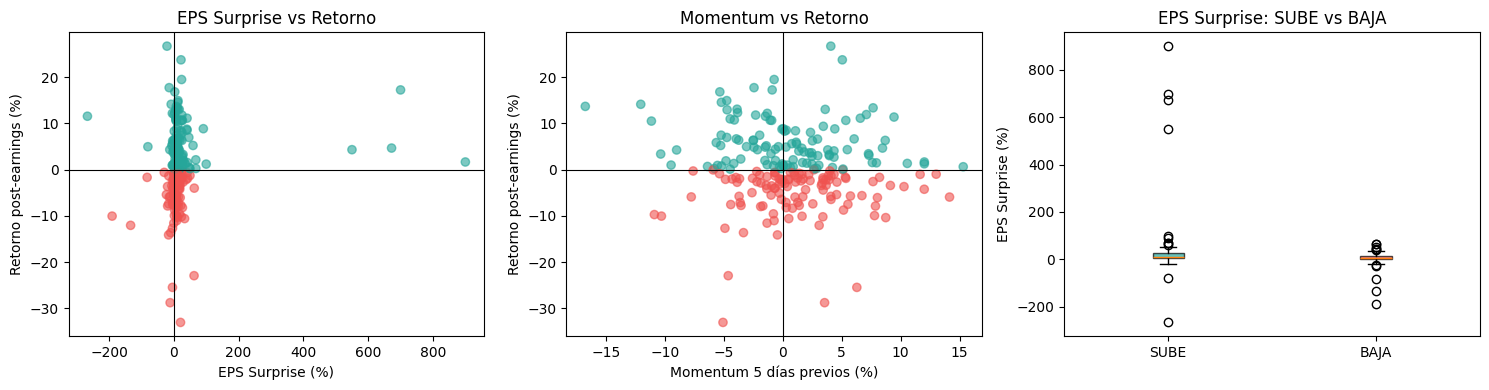

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# EPS surprise vs retorno
df_plot = df_merged.dropna(subset=["eps_surprise_pct"])
colores_eps = ["#26a69a" if d == "SUBE" else "#ef5350" for d in df_plot["direccion"]]
colores_all = ["#26a69a" if d == "SUBE" else "#ef5350" for d in df_merged["direccion"]]
axes[0].scatter(df_plot["eps_surprise_pct"], df_plot["retorno_pct"], c=colores_eps, alpha=0.6)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("EPS Surprise (%)")
axes[0].set_ylabel("Retorno post-earnings (%)")
axes[0].set_title("EPS Surprise vs Retorno")

# Momentum 5d vs retorno
axes[1].scatter(df_merged["momentum_5d"], df_merged["retorno_pct"], c=colores_all, alpha=0.6)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Momentum 5 días previos (%)")
axes[1].set_ylabel("Retorno post-earnings (%)")
axes[1].set_title("Momentum vs Retorno")

# Boxplots EPS surprise por dirección
grupos = [df_plot[df_plot["direccion"] == d]["eps_surprise_pct"].dropna() for d in ["SUBE", "BAJA"]]
bp = axes[2].boxplot(grupos, labels=["SUBE", "BAJA"], patch_artist=True)
for patch, color in zip(bp["boxes"], ["#26a69a", "#ef5350"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_title("EPS Surprise: SUBE vs BAJA")
axes[2].set_ylabel("EPS Surprise (%)")

plt.tight_layout()
plt.savefig("../outputs/features_analisis.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Encoding y construcción de la matriz final

In [26]:
df_features = df_merged.copy()

# Target basado en retorno a 5 días hábiles (captura el PEAD, menos ruido que 1d)
UMBRAL_RETORNO_5D = 3.0
df_features['target'] = (df_features['retorno_5d'] > UMBRAL_RETORNO_5D).astype(int)

n_pos = df_features['target'].sum()
n_neg = len(df_features) - n_pos
print(f'Target (retorno_5d > {UMBRAL_RETORNO_5D}%): {n_pos} SUBE | {n_neg} BAJA | total={len(df_features)}')
print(f'Ratio de clases: {n_neg/n_pos:.2f}:1')

# Encoding kw_categoria
kw_map = {'positivo': 1, 'neutral': 0, 'negativo': -1}
df_features['kw_cat_enc'] = df_features['kw_categoria'].map(kw_map).fillna(0).astype(int)

# Imputar EPS surprise faltante con la mediana
mediana_eps = df_features['eps_surprise_pct'].median()
df_features['eps_surprise_pct'] = df_features['eps_surprise_pct'].fillna(mediana_eps)

feature_cols = [
    # EPS (señal más fuerte)
    'eps_surprise_pct', 'eps_surprise_trend', 'eps_surprise_zscore',
    # Precio
    'momentum_5d', 'momentum_20d', 'volatility_20d', 'momentum_agreement',
    # FinBERT
    'score_positivo', 'score_negativo', 'score_neutral', 'polaridad',
    # Keywords
    'kw_positivos', 'kw_negativos', 'kw_ratio', 'kw_cat_enc',
    # NLP del texto crudo
    'uncertainty_score', 'forward_guidance_score', 'text_length_log',
    'question_density', 'negative_words_score',
    # Flag transcripción
    'tiene_transcripcion',
]

X = df_features[feature_cols]
y = df_features['target']

print(f'\nX shape: {X.shape}  ({X.shape[0]} muestras × {X.shape[1]} features)')
print(f'Target: {y.value_counts().to_dict()}  (0=BAJA/neutral, 1=SUBE>3% en 5d)')
print(f'\nFeatures ({len(feature_cols)}):')
for col in feature_cols:
    print(f'  {col}')

Target (retorno_5d > 3.0%): 89 SUBE | 139 BAJA | total=228
Ratio de clases: 1.56:1

X shape: (228, 21)  (228 muestras × 21 features)
Target: {0: 139, 1: 89}  (0=BAJA/neutral, 1=SUBE>3% en 5d)

Features (21):
  eps_surprise_pct
  eps_surprise_trend
  eps_surprise_zscore
  momentum_5d
  momentum_20d
  volatility_20d
  momentum_agreement
  score_positivo
  score_negativo
  score_neutral
  polaridad
  kw_positivos
  kw_negativos
  kw_ratio
  kw_cat_enc
  uncertainty_score
  forward_guidance_score
  text_length_log
  question_density
  negative_words_score
  tiene_transcripcion


## 8. Correlación con el retorno

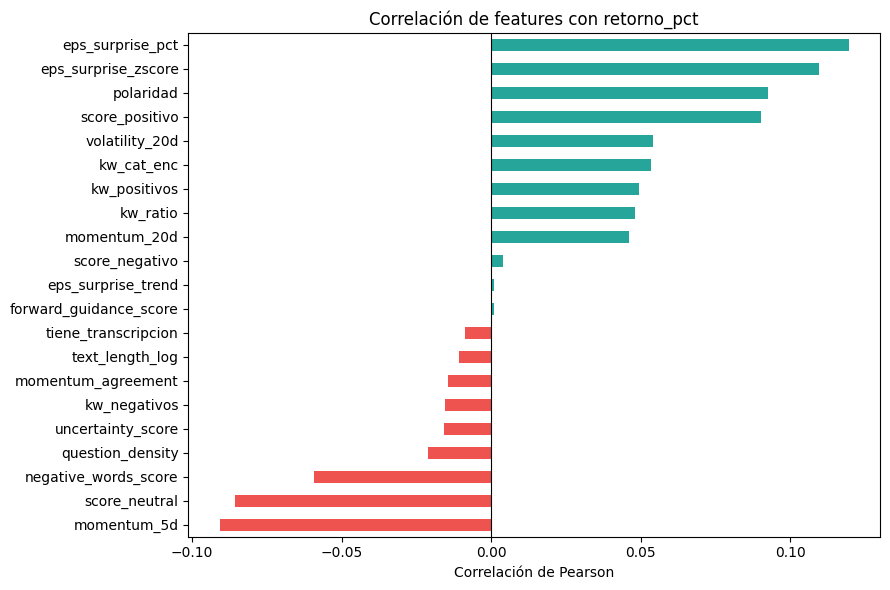

Top 5 features más correlacionadas con el retorno:
eps_surprise_pct       0.1194
eps_surprise_zscore    0.1096
polaridad              0.0926
momentum_5d            0.0907
score_positivo         0.0901
Name: retorno_pct, dtype: float64


In [27]:
corr = df_features[feature_cols + ['retorno_pct']].corr()['retorno_pct'].drop('retorno_pct')
corr_sorted = corr.sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#26a69a' if v > 0 else '#ef5350' for v in corr_sorted]
corr_sorted.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de features con retorno_pct', fontsize=12)
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.savefig('../outputs/correlacion_features.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 5 features más correlacionadas con el retorno:')
print(corr.abs().sort_values(ascending=False).head(5).round(4))

## 9. Guardar

In [28]:
cols_meta = ['ticker', 'q', 'fecha_earnings', 'retorno_pct', 'retorno_5d', 'direccion', 'target']
df_final = pd.concat([df_features[cols_meta], X], axis=1)

df_final.to_csv('../data/features.csv', index=False)
print(f'Guardado en data/features.csv')
print(f'Shape: {df_final.shape}')
print(f'\nDistribución target: {df_final["target"].value_counts().to_dict()}  (0=BAJA, 1=SUBE>3% en 5d)')
print(f'\nColumnas guardadas:')
print(list(df_final.columns))
df_final.head()

Guardado en data/features.csv
Shape: (228, 28)

Distribución target: {0: 139, 1: 89}  (0=BAJA, 1=SUBE>3% en 5d)

Columnas guardadas:
['ticker', 'q', 'fecha_earnings', 'retorno_pct', 'retorno_5d', 'direccion', 'target', 'eps_surprise_pct', 'eps_surprise_trend', 'eps_surprise_zscore', 'momentum_5d', 'momentum_20d', 'volatility_20d', 'momentum_agreement', 'score_positivo', 'score_negativo', 'score_neutral', 'polaridad', 'kw_positivos', 'kw_negativos', 'kw_ratio', 'kw_cat_enc', 'uncertainty_score', 'forward_guidance_score', 'text_length_log', 'question_density', 'negative_words_score', 'tiene_transcripcion']


,ticker,q,fecha_earnings,retorno_pct,retorno_5d,direccion,target,eps_surprise_pct,eps_surprise_trend,eps_surprise_zscore,...,kw_positivos,kw_negativos,kw_ratio,kw_cat_enc,uncertainty_score,forward_guidance_score,text_length_log,question_density,negative_words_score,tiene_transcripcion
0,AAPL,2020-Q1,2020-01-28,4.98,0.3652,SUBE,0,10.6195,0.00000,0.093321,...,1.0,0.0,0.5000,1,1.7956,0.2762,6.5862,0.2093,0.0000,1
1,AAPL,2020-Q2,2020-04-30,0.47,3.3833,SUBE,1,14.2857,10.61950,0.423872,...,1.0,1.0,0.0000,0,0.6906,0.0000,6.5862,0.1136,0.2762,1
2,AAPL,2020-Q3,2020-07-30,11.81,18.4140,SUBE,1,25.0000,12.45260,1.389892,...,1.0,1.0,0.0000,0,0.9589,0.2740,6.5944,0.1818,0.1370,1
3,AAPL,2020-Q4,2020-10-29,-2.10,3.2171,BAJA,1,4.2857,19.64285,-0.477745,...,2.0,0.0,0.6667,1,1.3514,0.2703,6.6080,0.1458,0.0000,1
4,AAPL,2021-Q1,2021-01-27,-4.24,-5.7159,BAJA,0,18.3099,14.64285,0.786701,...,3.0,0.0,0.7500,1,0.6460,0.2584,6.6529,0.0784,0.0000,1
